In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [ ]:
# 2: Load dataset
df = pd.read_csv("day.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# 2: Load dataset
df = pd.read_csv("hour.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
# 4: Drop unnecessary columns
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

In [ ]:
# 5: Convert target (cnt → High/Low demand)
threshold = df['cnt'].median()
df['demand'] = df['cnt'].apply(lambda x: 1 if x > threshold else 0)


In [ ]:
# Drop original cnt
df = df.drop('cnt', axis=1)

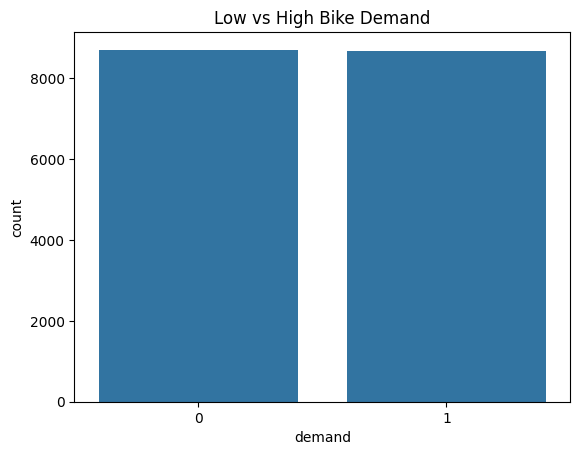

In [ ]:
# 6: Visualization
sns.countplot(x='demand', data=df)
plt.title("Low vs High Bike Demand")
plt.show()


In [ ]:
# 7: Encoding (if needed)
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [ ]:
# 8: Features & Target
X = df.drop("demand", axis=1)
y = df["demand"]


In [ ]:
# 9: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Result storage
results_8020 = []
results_7030 = []

In [ ]:
# =========================
# 10: Logistic Regression
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
acc_lr_80 = accuracy_score(y_test, lr.predict(X_test))
results_8020.append(['Logistic Regression', acc_lr_80])

In [ ]:
# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
lr.fit(X_train, y_train)
acc_lr_70 = accuracy_score(y_test, lr.predict(X_test))
results_7030.append(['Logistic Regression', acc_lr_70])

In [ ]:
# =========================
# 11: Decision Tree
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
acc_dt_80 = accuracy_score(y_test, dt.predict(X_test))
results_8020.append(['Decision Tree', acc_dt_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
dt.fit(X_train, y_train)
acc_dt_70 = accuracy_score(y_test, dt.predict(X_test))
results_7030.append(['Decision Tree', acc_dt_70])

# =========================
# 12: Random Forest
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
acc_rf_80 = accuracy_score(y_test, rf.predict(X_test))
results_8020.append(['Random Forest', acc_rf_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
rf.fit(X_train, y_train)
acc_rf_70 = accuracy_score(y_test, rf.predict(X_test))
results_7030.append(['Random Forest', acc_rf_70])

# =========================
# 13: SVM
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
svm = SVC()
svm.fit(X_train, y_train)
acc_svm_80 = accuracy_score(y_test, svm.predict(X_test))
results_8020.append(['SVM', acc_svm_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
svm.fit(X_train, y_train)
acc_svm_70 = accuracy_score(y_test, svm.predict(X_test))
results_7030.append(['SVM', acc_svm_70])

# =========================
# 14: KNN
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_knn_80 = accuracy_score(y_test, knn.predict(X_test))
results_8020.append(['KNN', acc_knn_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
knn.fit(X_train, y_train)
acc_knn_70 = accuracy_score(y_test, knn.predict(X_test))
results_7030.append(['KNN', acc_knn_70])

# =========================
# 15: Naive Bayes
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
nb = GaussianNB()
nb.fit(X_train, y_train)
acc_nb_80 = accuracy_score(y_test, nb.predict(X_test))
results_8020.append(['Naive Bayes', acc_nb_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
nb.fit(X_train, y_train)
acc_nb_70 = accuracy_score(y_test, nb.predict(X_test))
results_7030.append(['Naive Bayes', acc_nb_70])

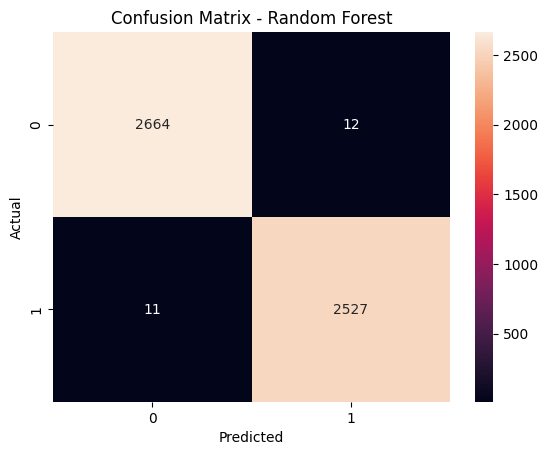

In [ ]:
# =========================
# 16: Confusion Matrix
# =========================

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# =========================
# 17: Metrics
# =========================

print("Precision:", precision_score(y_test, rf.predict(X_test)))
print("Recall:", recall_score(y_test, rf.predict(X_test)))
print("F1 Score:", f1_score(y_test, rf.predict(X_test)))


Precision: 0.9952737298148877
Recall: 0.9956658786446021
F1 Score: 0.995469765609612


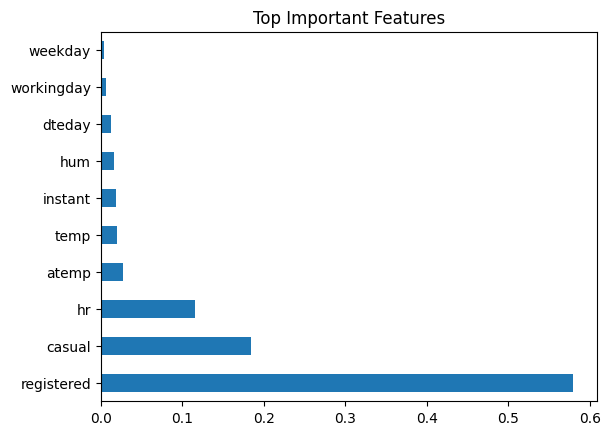

In [ ]:
# =========================
# 18: Feature Importance
# =========================

importances = rf.feature_importances_
feature_names = X.columns
feature_imp = pd.Series(importances, index=feature_names)

feature_imp.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

In [ ]:
# =========================
# 19: Final Tables
# =========================

df_8020 = pd.DataFrame(results_8020, columns=['Model', 'Accuracy'])
df_7030 = pd.DataFrame(results_7030, columns=['Model', 'Accuracy'])

print("\n==============================")
print("80:20 SPLIT PERFORMANCE")
print("==============================")
print(df_8020)

print("\n==============================")
print("70:30 SPLIT PERFORMANCE")
print("==============================")
print(df_7030)


80:20 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.995972
1        Decision Tree  0.995397
2        Random Forest  0.996260
3                  SVM  0.984177
4                  KNN  0.925489
5          Naive Bayes  0.954258

70:30 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.995972
1        Decision Tree  0.995013
2        Random Forest  0.995589
3                  SVM  0.982739
4                  KNN  0.925010
5          Naive Bayes  0.953011


In [ ]:
# =========================
# Final Classification Metrics
# =========================

from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "Naive Bayes": nb
}

print("\n===== Classification Metrics (80:20 Split) =====")

# Use last 80:20 split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}:")
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))


===== Classification Metrics (80:20 Split) =====

Decision Tree:
Precision: 0.9956863441227856
Recall   : 0.9956846950517837
F1 Score : 0.9956847775941849

Random Forest:
Precision: 0.9959723820483314
Recall   : 0.9959723820483314
F1 Score : 0.9959723820483314

SVM:
Precision: 0.984220022883768
Recall   : 0.9841772151898734
F1 Score : 0.984175054052522

KNN:
Precision: 0.9256651995587366
Recall   : 0.9254890678941312
F1 Score : 0.9254604141532793

Naive Bayes:
Precision: 0.9542609396308808
Recall   : 0.9542577675489068
F1 Score : 0.9542586424983606


In [ ]:
# =========================
# Regression Models + Evaluation
# =========================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train-test split (use once)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# Evaluation
print("===== Regression Model Performance =====")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

===== Regression Model Performance =====

Linear Regression:
MAE : 0.25984509628008245
RMSE: 0.3108643177367011
R2  : 0.6132486461377376

Decision Tree Regressor:
MAE : 0.0037399309551208286
RMSE: 0.06115497490082739
R2  : 0.9850323479883036

Random Forest Regressor:
MAE : 0.004729574223245109
RMSE: 0.045964913821813266
R2  : 0.9915444279712385

Gradient Boosting Regressor:
MAE : 0.014642698502535826
RMSE: 0.06226064304187083
R2  : 0.9844862318494698

SVR:
MAE : 0.13640155690759412
RMSE: 0.19709084011863615
R2  : 0.8445384567937329

KNN Regressor:
MAE : 0.10667433831990793
RMSE: 0.23132181340695615
R2  : 0.7858474404480358


In [ ]:
# =========================
# Regression Models (80:20 and 70:30)
# =========================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

# Function to evaluate
def evaluate_split(test_size, split_name):
    print(f"\n===== Results for {split_name} Split =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"\n{name}:")
        print("MAE :", mae)
        print("RMSE:", rmse)
        print("R2  :", r2)

# Run for both splits
evaluate_split(0.2, "80:20")
evaluate_split(0.3, "70:30")


===== Results for 80:20 Split =====

Linear Regression:
MAE : 0.32812796607605127
RMSE: 0.3962678282455221
R2  : 0.37155435283914695

Decision Tree:
MAE : 0.08803222094361335
RMSE: 0.29670224290290315
R2  : 0.6476844988016074

Random Forest:
MAE : 0.09621116225546605
RMSE: 0.21323006316862378
R2  : 0.818035376099189

Gradient Boosting:
MAE : 0.18330635975135115
RMSE: 0.26961610936154046
R2  : 0.7090745144444311

SVR:
MAE : 0.21297249021316866
RMSE: 0.3109555857182476
R2  : 0.6130215168400948

KNN:
MAE : 0.19884925201380899
RMSE: 0.33011488044662574
R2  : 0.5638656475361074

===== Results for 70:30 Split =====

Linear Regression:
MAE : 0.32690496313840456
RMSE: 0.3934003190647341
R2  : 0.38051079567813406

Decision Tree:
MAE : 0.0918680475642501
RMSE: 0.30309742256286193
R2  : 0.6322702102923456

Random Forest:
MAE : 0.09846566935174532
RMSE: 0.21685684020710683
R2  : 0.8117605792845608

Gradient Boosting:
MAE : 0.18271796985932862
RMSE: 0.27051109662513634
R2  : 0.7070897990449171

SV

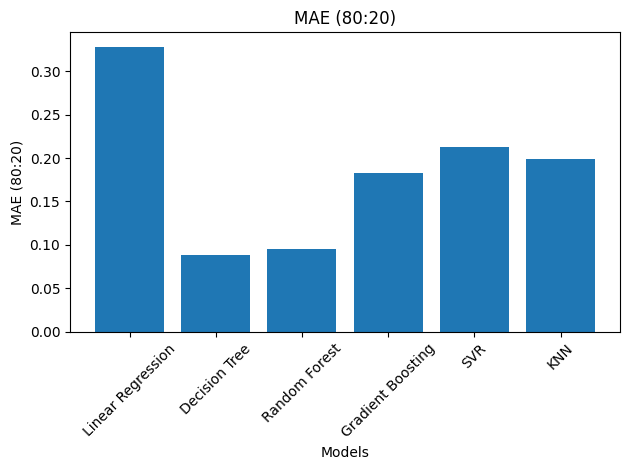

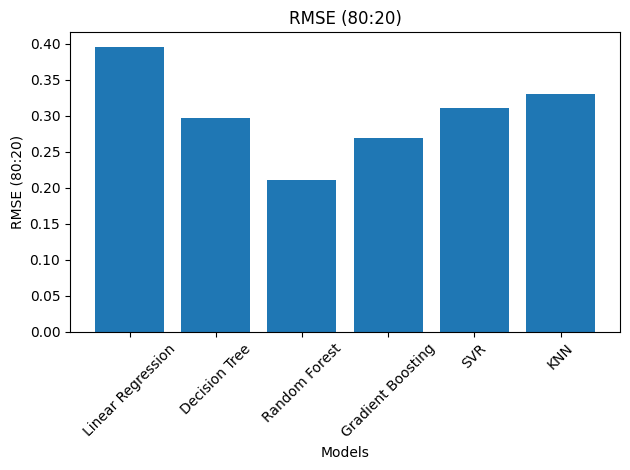

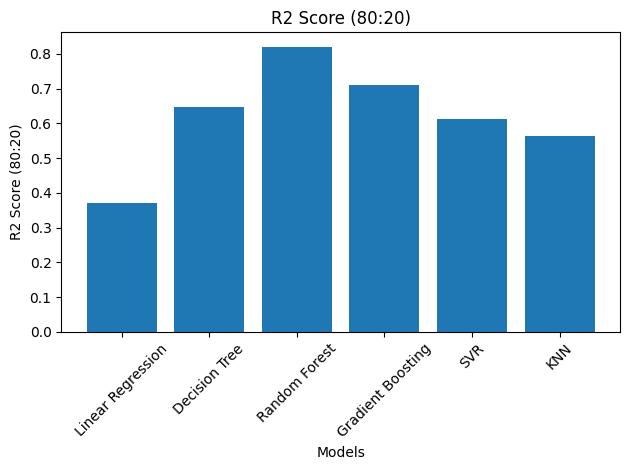

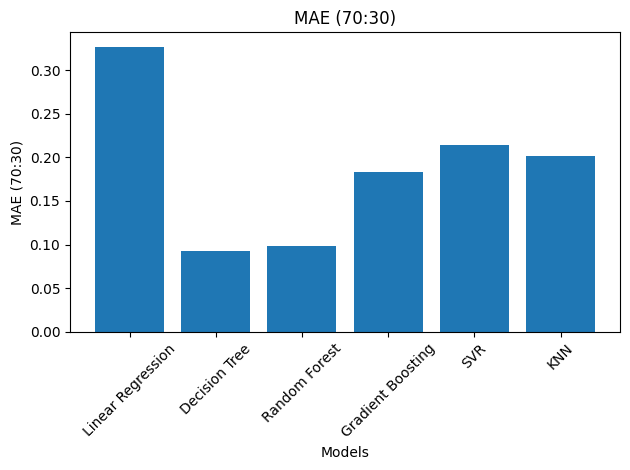

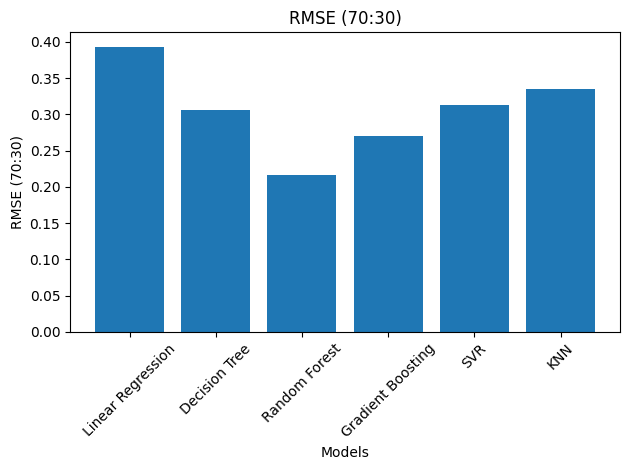

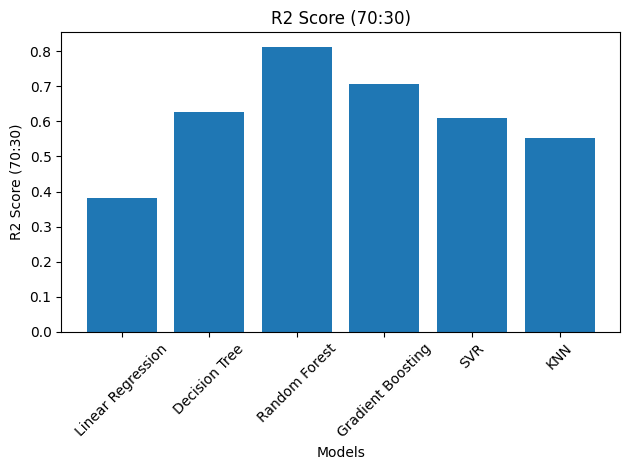

In [ ]:
import matplotlib.pyplot as plt

# Store results
results_8020 = []
results_7030 = []

def evaluate_and_store(test_size, results_list):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results_list.append([name, mae, rmse, r2])

# Run for both splits
evaluate_and_store(0.2, results_8020)
evaluate_and_store(0.3, results_7030)

# Function to plot
def plot_metric(results, metric_index, title):
    model_names = [r[0] for r in results]
    values = [r[metric_index] for r in results]

    plt.figure()
    plt.bar(model_names, values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Models")
    plt.ylabel(title)
    plt.tight_layout()
    plt.show()

# Plot graphs for 80:20
plot_metric(results_8020, 1, "MAE (80:20)")
plot_metric(results_8020, 2, "RMSE (80:20)")
plot_metric(results_8020, 3, "R2 Score (80:20)")

# Plot graphs for 70:30
plot_metric(results_7030, 1, "MAE (70:30)")
plot_metric(results_7030, 2, "RMSE (70:30)")
plot_metric(results_7030, 3, "R2 Score (70:30)")

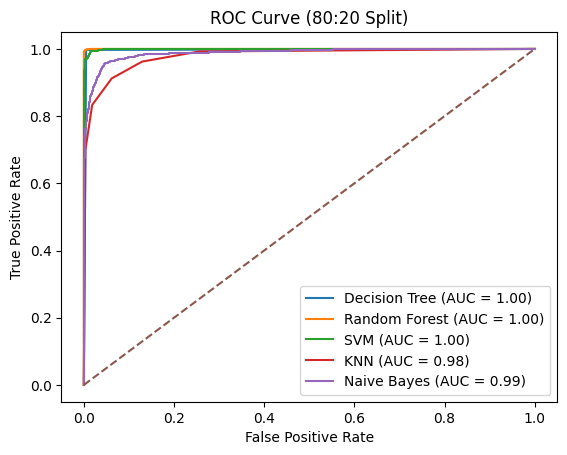

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example: using 80:20 split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "Naive Bayes": nb
}

plt.figure()

for name, model in models.items():
    model.fit(X_train, y_train)

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (80:20 Split)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Create empty lists
results_8020 = []
results_7030 = []

def evaluate_and_store(test_size, results_list):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results_list.append([name, mae, rmse, r2])

# Run
evaluate_and_store(0.2, results_8020)
evaluate_and_store(0.3, results_7030)

# Convert to DataFrame
df_8020 = pd.DataFrame(results_8020, columns=["Model", "MAE", "RMSE", "R2"])
df_7030 = pd.DataFrame(results_7030, columns=["Model", "MAE", "RMSE", "R2"])

# Display tables
print("\n===== 80:20 Split Results =====")
print(df_8020)

print("\n===== 70:30 Split Results =====")
print(df_7030)


===== 80:20 Split Results =====
           Model       MAE      RMSE        R2
0  Decision Tree  0.004891  0.069933  0.980427
1  Random Forest  0.003165  0.056254  0.987335
2            SVM  0.015823  0.125789  0.936675
3            KNN  0.074511  0.272967  0.701798
4    Naive Bayes  0.045742  0.213874  0.816934

===== 70:30 Split Results =====
           Model       MAE      RMSE        R2
0  Decision Tree  0.004795  0.069244  0.980807
1  Random Forest  0.004603  0.067845  0.981575
2            SVM  0.017261  0.131382  0.930907
3            KNN  0.074990  0.273844  0.699828
4    Naive Bayes  0.046989  0.216769  0.811913


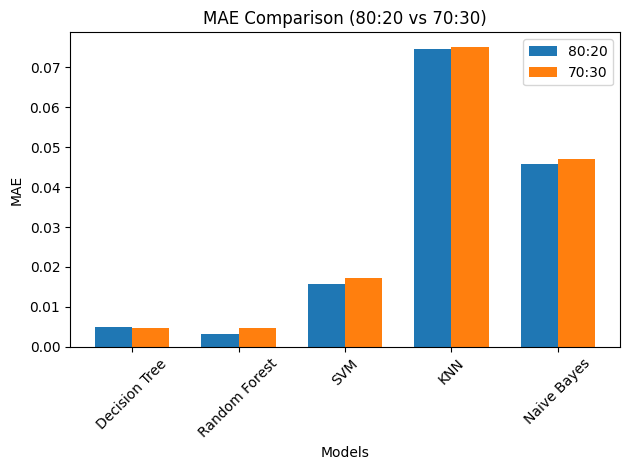

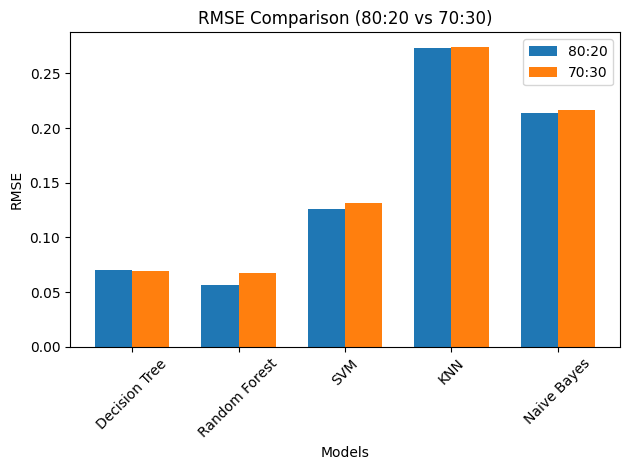

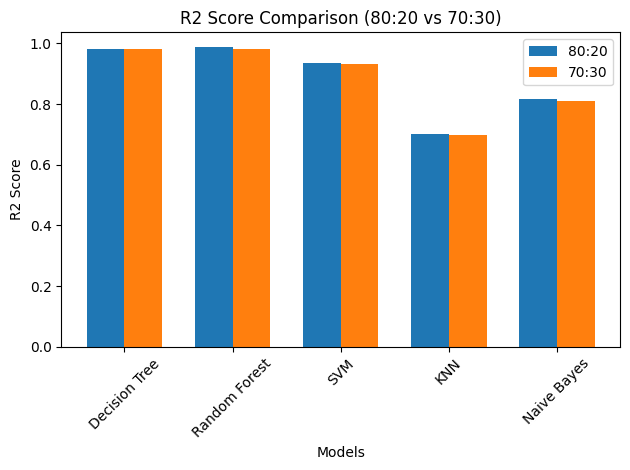

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract model names
model_names = [r[0] for r in results_8020]

# Extract metrics
mae_8020 = [r[1] for r in results_8020]
rmse_8020 = [r[2] for r in results_8020]
r2_8020 = [r[3] for r in results_8020]

mae_7030 = [r[1] for r in results_7030]
rmse_7030 = [r[2] for r in results_7030]
r2_7030 = [r[3] for r in results_7030]

x = np.arange(len(model_names))
width = 0.35

# ==============================
# 📊 MAE COMPARISON
# ==============================
plt.figure()
plt.bar(x - width/2, mae_8020, width, label='80:20')
plt.bar(x + width/2, mae_7030, width, label='70:30')

plt.xticks(x, model_names, rotation=45)
plt.title("MAE Comparison (80:20 vs 70:30)")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 📊 RMSE COMPARISON
# ==============================
plt.figure()
plt.bar(x - width/2, rmse_8020, width, label='80:20')
plt.bar(x + width/2, rmse_7030, width, label='70:30')

plt.xticks(x, model_names, rotation=45)
plt.title("RMSE Comparison (80:20 vs 70:30)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 📊 R2 COMPARISON
# ==============================
plt.figure()
plt.bar(x - width/2, r2_8020, width, label='80:20')
plt.bar(x + width/2, r2_7030, width, label='70:30')

plt.xticks(x, model_names, rotation=45)
plt.title("R2 Score Comparison (80:20 vs 70:30)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.legend()
plt.tight_layout()
plt.show()

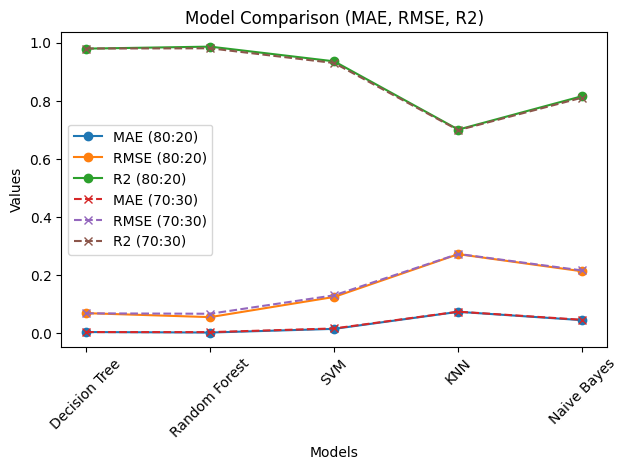

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model names
model_names = [r[0] for r in results_8020]

# Metrics for 80:20
mae_8020 = [r[1] for r in results_8020]
rmse_8020 = [r[2] for r in results_8020]
r2_8020 = [r[3] for r in results_8020]

# Metrics for 70:30
mae_7030 = [r[1] for r in results_7030]
rmse_7030 = [r[2] for r in results_7030]
r2_7030 = [r[3] for r in results_7030]

# Plot
plt.figure()

# 80:20 lines
plt.plot(model_names, mae_8020, marker='o', label='MAE (80:20)')
plt.plot(model_names, rmse_8020, marker='o', label='RMSE (80:20)')
plt.plot(model_names, r2_8020, marker='o', label='R2 (80:20)')

# 70:30 lines
plt.plot(model_names, mae_7030, marker='x', linestyle='--', label='MAE (70:30)')
plt.plot(model_names, rmse_7030, marker='x', linestyle='--', label='RMSE (70:30)')
plt.plot(model_names, r2_7030, marker='x', linestyle='--', label='R2 (70:30)')

# Labels
plt.title("Model Comparison (MAE, RMSE, R2)")
plt.xlabel("Models")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

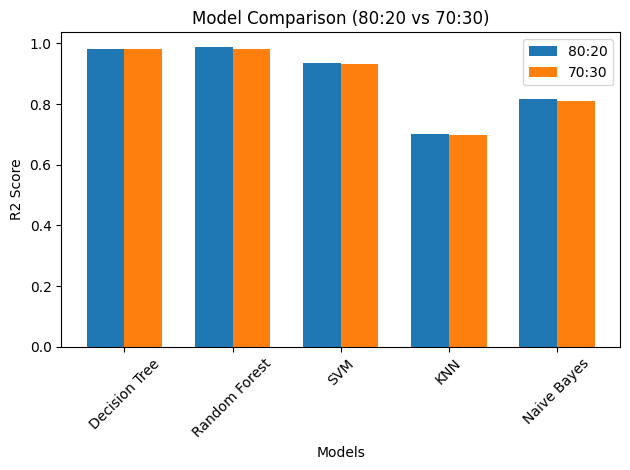

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
model_names = [r[0] for r in results_8020]

# Choose metric (here using R2 — best for regression)
metric_8020 = [r[3] for r in results_8020]   # R2 for 80:20
metric_7030 = [r[3] for r in results_7030]   # R2 for 70:30

x = np.arange(len(model_names))
width = 0.35

plt.figure()

plt.bar(x - width/2, metric_8020, width, label='80:20')
plt.bar(x + width/2, metric_7030, width, label='70:30')

plt.xticks(x, model_names, rotation=45)
plt.title("Model Comparison (80:20 vs 70:30)")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.legend()
plt.tight_layout()
plt.show()